The big Idea is that I want to see if I can use all the item 1 data to train a general model, and then unfreeze layers to just do 1 item

In [20]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [21]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial

# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss

In [22]:
class simple_net(nn.Module):
    def __init__(self,input_size, hidden_size=10, output_size=1):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)
    
    def freeze_layers_1_2(self):
        # Must set requires_grad on Parameters, not on the Module
        self.fc1.requires_grad_(False)
        self.fc2.requires_grad_(False)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [23]:
all_specs = [
    "7_day_rolling_ema",	
    "7_day_rolling_mean",	
    "30_day_rolling_ema",	
    "diff_180_day",	
    "diff_90_day",	
    "30_day_rolling_mean",	
    "diff_30_day",	
    "7_day_rolling_min",	
    "7_day_lag",	
    "30_day_rolling_min",	
    "14_day_lag",	
    "diff_365_day",	
]

In [24]:
# Get data for item 1, store 1
train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    data_mask=[
        ("item", 1),
        ("store", 1)
    ],
    specs=all_specs,
    )

In [25]:
h_cost = 1
l_cost = 3

Training: 100%|██████████| 200/200 [00:08<00:00, 24.06step/s, train_loss=5.5604]                   


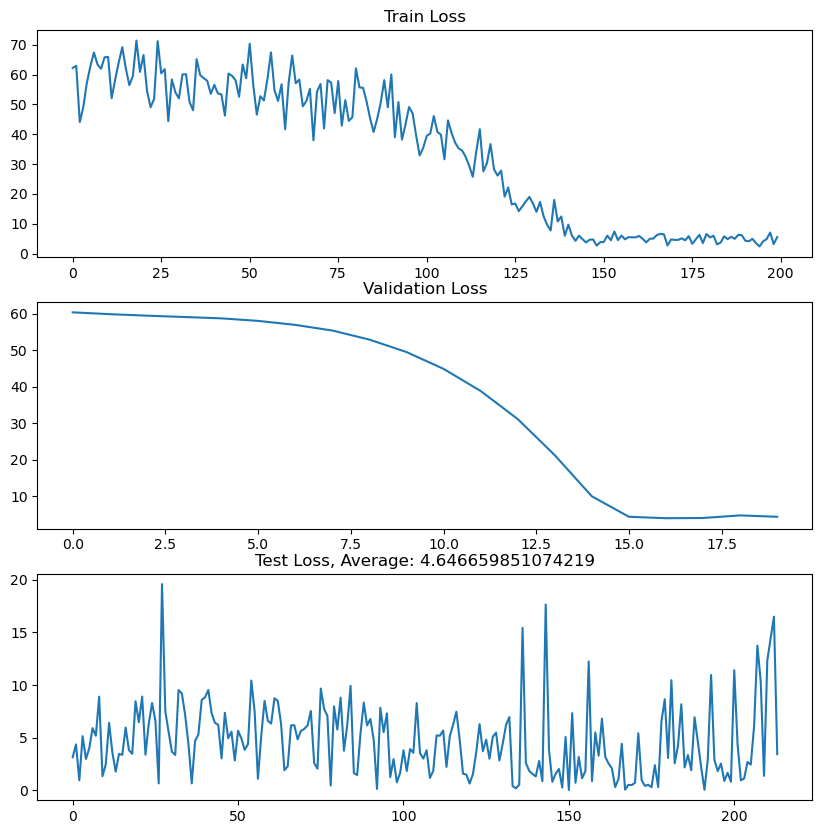

In [26]:

net_1 = simple_net(train_loader.dataset.x.shape[1], hidden_size=train_loader.dataset.x.shape[1], output_size=train_loader.dataset.y.shape[1])
loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net_1.parameters(), lr=0.001)

train_losses, val_losses = train(net_1, optimizer, loss, train_loader, val_loader, epochs=200, eval_interval=10, device="cpu")

test_loss = get_test_loss(net_1, test_loader, loss, "cpu")

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
axs[0].plot(train_losses)
axs[0].set_title("Train Loss")
axs[1].plot(val_losses)
axs[1].set_title("Validation Loss")
axs[2].plot(test_loss)
axs[2].set_title(f"Test Loss, Average: {torch.tensor(test_loss).mean()}")
plt.show()

In [27]:
# Get data for item 1, store 1
all_train_loader, all_val_loader, _ = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    specs=all_specs,
    )

Training: 100%|██████████| 100/100 [04:26<00:00,  2.67s/step, train_loss=12.0790]                   


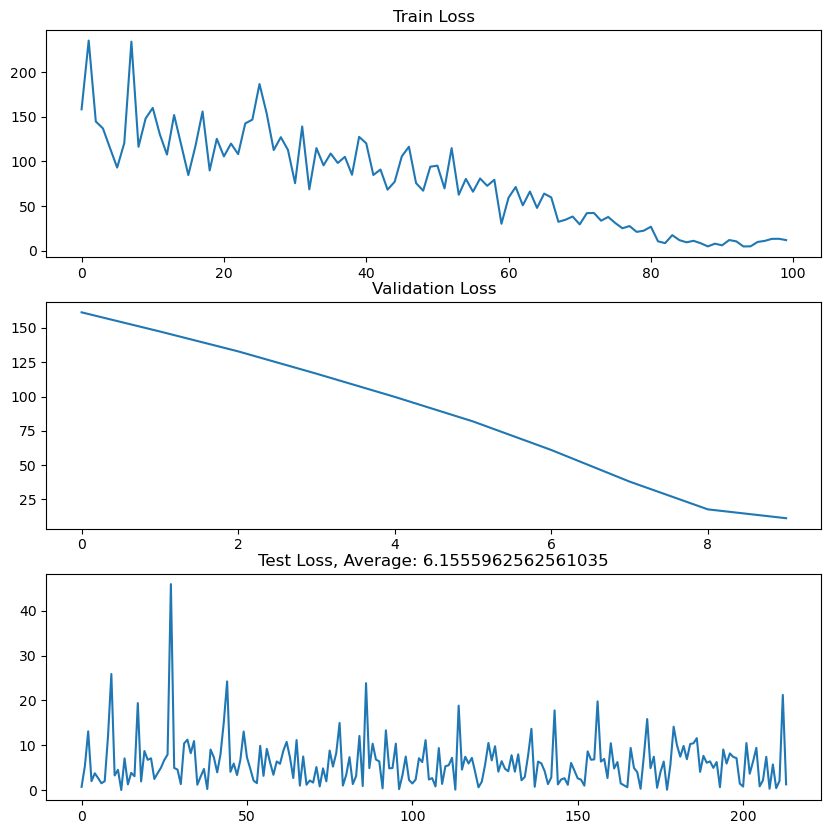

In [28]:
net_2 = simple_net(all_train_loader.dataset.x.shape[1], hidden_size=all_train_loader.dataset.x.shape[1], output_size=all_train_loader.dataset.y.shape[1])
loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net_2.parameters(), lr=0.001)

train_losses, val_losses = train(net_2, optimizer, loss, all_train_loader, all_val_loader, epochs=100, eval_interval=10, device="cpu")

test_loss = get_test_loss(net_2, test_loader, loss, "cpu")

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
axs[0].plot(train_losses)
axs[0].set_title("Train Loss")
axs[1].plot(val_losses)
axs[1].set_title("Validation Loss")
axs[2].plot(test_loss)
axs[2].set_title(f"Test Loss, Average: {torch.tensor(test_loss).mean()}")
plt.show()

Training: 100%|██████████| 200/200 [00:07<00:00, 25.17step/s, train_loss=11.5119]                


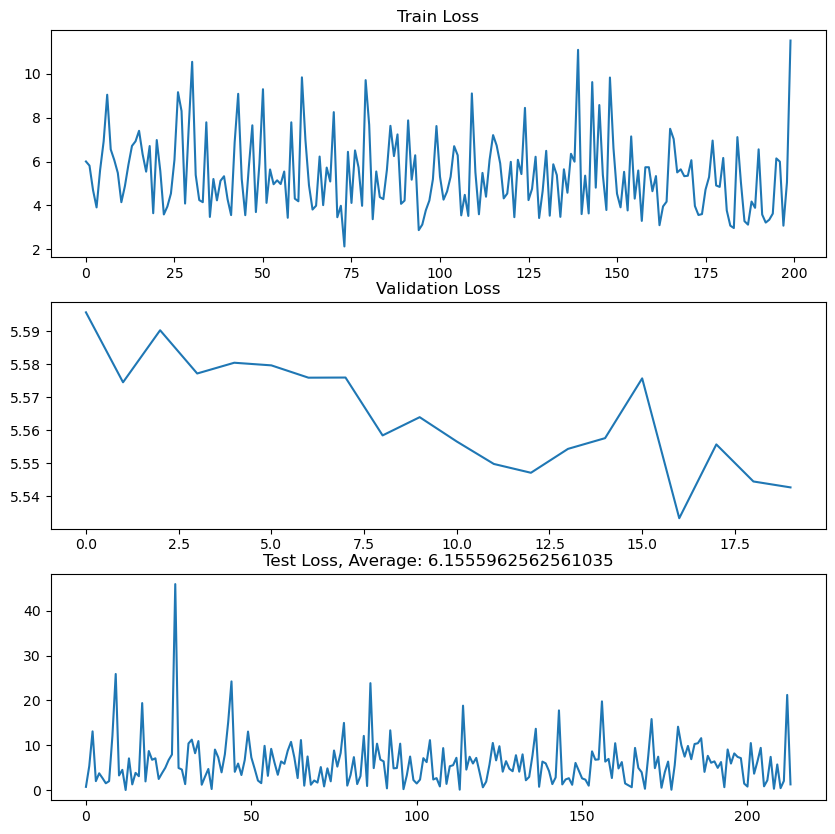

In [30]:
# Freeze net 2: only fc3 trains
net_2.freeze_layers_1_2()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, net_2.parameters()),
    lr=0.001,
)

# Fine-tune on single (item, store) loaders
train_losses, val_losses = train(net_2, optimizer, loss, train_loader, val_loader, epochs=200, eval_interval=10, device="cpu")

fig, axs = plt.subplots(3, 1, figsize=(10, 10))
axs[0].plot(train_losses)
axs[0].set_title("Train Loss")
axs[1].plot(val_losses)
axs[1].set_title("Validation Loss")
axs[2].plot(test_loss)
axs[2].set_title(f"Test Loss, Average: {torch.tensor(test_loss).mean()}")
plt.show()